In [1]:
!pip install yfinance pandas matplotlib seaborn

Saved: AAPL.csv
Saved: NVDA.csv
Saved: TSLA.csv
Saved: AMZN.csv
Saved: MSFT.csv

===== AAPL Statistics =====
             Open        High         Low       Close        Volume  \
count  250.000000  250.000000  250.000000  250.000000  2.500000e+02   
mean   241.294051  243.714420  238.937695  241.358179  5.025384e+07   
std     27.791915   28.002647   27.610082   27.813731  1.875090e+07   
min    192.431316  192.959015  188.986324  192.321793  1.791060e+07   
25%    210.250188  212.772510  208.916743  211.000828  3.946608e+07   
50%    252.306866  254.970001  248.535004  251.725014  4.645605e+07   
75%    263.572502  267.179901  261.397984  264.522491  5.462505e+07   
max    285.932471  288.350192  283.035157  285.922455  1.637413e+08   

        Dividends  Stock Splits  
count  250.000000         250.0  
mean     0.004160           0.0  
std      0.032689           0.0  
min      0.000000           0.0  
25%      0.000000           0.0  
50%      0.000000           0.0  
75%      0.00

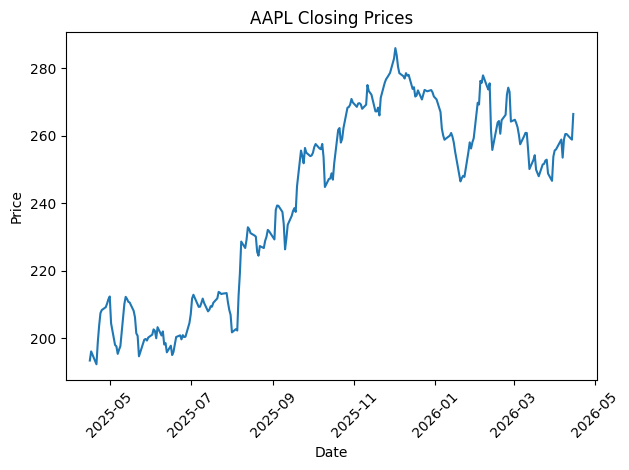

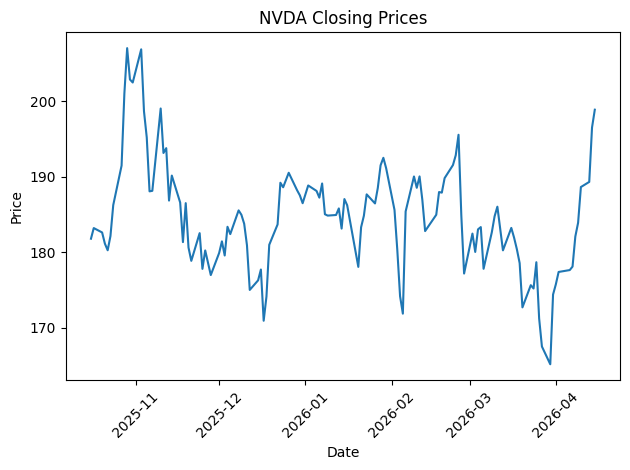

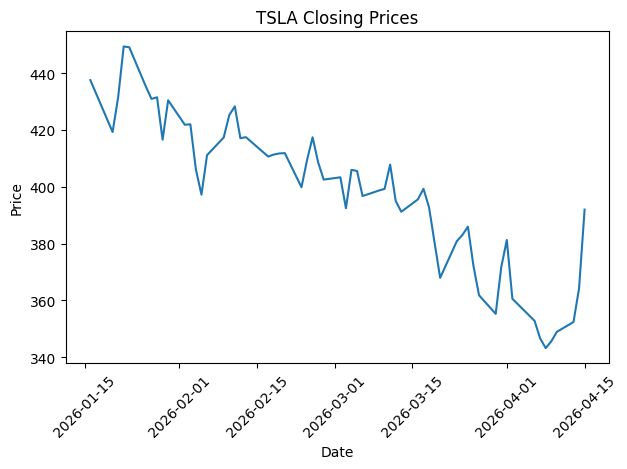

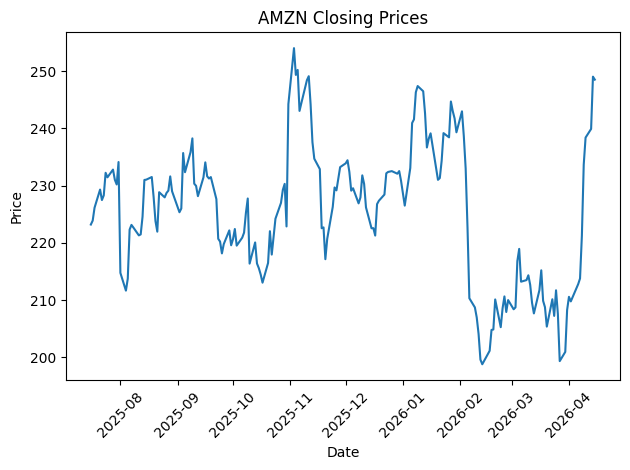

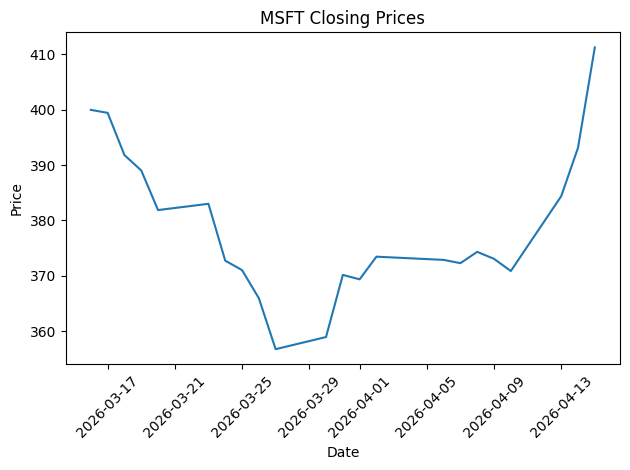

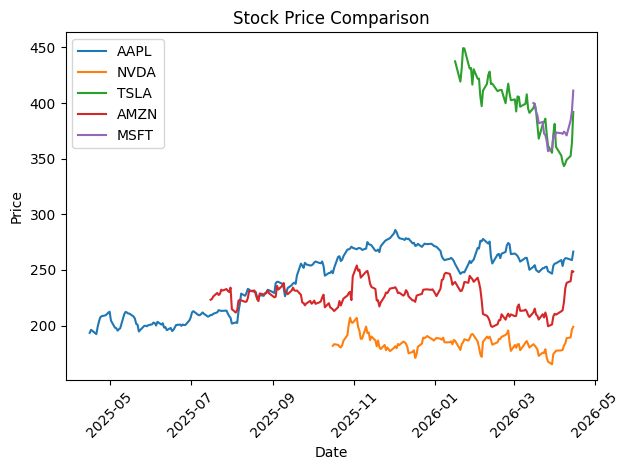

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
# ==============================
# 1. Install & import libraries
# ==============================
!pip install yfinance

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
companies = {
    "AAPL": "1y",
    "NVDA": "6mo",
    "TSLA": "3mo",
    "AMZN": "9mo",
    "MSFT": "1mo"
}

data = {}
for ticker, period in companies.items():
    df = yf.Ticker(ticker).history(period=period)
    df.reset_index(inplace=True)
    filename = f"{ticker}.csv"
    df.to_csv(filename, index=False)

    data[ticker] = df

    print(f"Saved: {filename}")
for ticker, df in data.items():
    print(f"\n===== {ticker} Statistics =====")
    print(df.describe())
for ticker, df in data.items():
    print(f"\n===== {ticker} KPI CHECK =====")
    print("Missing values:\n", df.isnull().sum())
    print("Latest date:", df["Date"].max())
    if (df["Close"] < 0).any():
        print("Warning: Negative prices found!")
    else:
        print("No negative prices (OK)")
    print("Columns:", list(df.columns))
for ticker, df in data.items():
    plt.figure()
    plt.plot(df["Date"], df["Close"])
    plt.title(f"{ticker} Closing Prices")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
plt.figure()

for ticker, df in data.items():
    plt.plot(df["Date"], df["Close"], label=ticker)

plt.title("Stock Price Comparison")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
for ticker in companies.keys():
    files.download(f"{ticker}.csv")